In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/several27/FakeNewsCorpus/master/news_sample.csv"
# Kept for testing
file_name = "995,000_rows.csv"
df = pd.read_csv(url)
df.head()

,Unnamed: 0,id,domain,type,url,content,scraped_at,inserted_at,updated_at,title,authors,keywords,meta_keywords,meta_description,tags,summary
0,0,141,awm.com,unreliable,http://awm.com/church-congregation-brings-gift...,Sometimes the power of Christmas will make you...,2018-01-25 16:17:44.789555,2018-02-02 01:19:41.756632,2018-02-02 01:19:41.756664,Church Congregation Brings Gift to Waitresses ...,Ruth Harris,NaN,[''],NaN,NaN,NaN
1,1,256,beforeitsnews.com,fake,http://beforeitsnews.com/awakening-start-here/...,AWAKENING OF 12 STRANDS of DNA – “Reconnecting...,2018-01-25 16:17:44.789555,2018-02-02 01:19:41.756632,2018-02-02 01:19:41.756664,AWAKENING OF 12 STRANDS of DNA – “Reconnecting...,Zurich Times,NaN,[''],NaN,NaN,NaN
2,2,700,cnnnext.com,unreliable,http://www.cnnnext.com/video/18526/never-hike-...,Never Hike Alone: A Friday the 13th Fan Film U...,2018-01-25 16:17:44.789555,2018-02-02 01:19:41.756632,2018-02-02 01:19:41.756664,Never Hike Alone - A Friday the 13th Fan Film ...,NaN,NaN,[''],Never Hike Alone: A Friday the 13th Fan Film ...,NaN,NaN
3,3,768,awm.com,unreliable,http://awm.com/elusive-alien-of-the-sea-caught...,"When a rare shark was caught, scientists were ...",2018-01-25 16:17:44.789555,2018-02-02 01:19:41.756632,2018-02-02 01:19:41.756664,Elusive ‘Alien Of The Sea ‘ Caught By Scientis...,Alexander Smith,NaN,[''],NaN,NaN,NaN
4,4,791,bipartisanreport.com,clickbait,http://bipartisanreport.com/2018/01/21/trumps-...,Donald Trump has the unnerving ability to abil...,2018-01-25 16:17:44.789555,2018-02-02 01:19:41.756632,2018-02-02 01:19:41.756664,Trump’s Genius Poll Is Complete & The Results ...,Gloria Christie,NaN,[''],NaN,NaN,NaN


In [2]:
from multiprocessing import Pool, cpu_count
import nltk

num_cores = cpu_count()

with Pool(num_cores) as pool:
    df["tokens"] = pool.map(nltk.word_tokenize, df["content"].astype(str))

In [3]:
import nltk
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from multiprocessing.pool import ThreadPool
from multiprocessing import cpu_count

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))
punctuation = set(string.punctuation)

def clean_tokens(text):
    tokens = word_tokenize(str(text))
    return [word for word in tokens
            if word.lower() not in stop_words
            and word not in punctuation
            and word.isalpha()]

num_cores = cpu_count()

with ThreadPool(num_cores) as pool:
    df["tokens_clean"] = pool.map(clean_tokens, df["content"])

print(df["tokens_clean"])

[nltk_data] Downloading package stopwords to /Users/lasse/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


0      [Sometimes, power, Christmas, make, wild, wond...
1      [AWAKENING, STRANDS, DNA, Reconnecting, Movie,...
2      [Never, Hike, Alone, Friday, Fan, Film, USA, m...
3      [rare, shark, caught, scientists, left, blunde...
4      [Donald, Trump, unnerving, ability, ability, c...
                             ...                        
245    [Prison, Rahm, God, Work, Many, Others, Headli...
246    [Useful, Items, Tiny, Home, Headline, Bitcoin,...
247    [Former, CIA, Director, Michael, Hayden, said,...
248    [Antonio, Sabato, says, Hollywood, liberal, el...
249    [Former, President, Bill, Clinton, Monday, cal...
Name: tokens_clean, Length: 250, dtype: object


In [4]:
from nltk.stem import PorterStemmer
from multiprocessing import cpu_count
from multiprocessing.pool import ThreadPool
stemmer = PorterStemmer()

def stem_tokens(tokens):
    return [stemmer.stem(w) for w in tokens]

num_cores = cpu_count()

with ThreadPool(num_cores) as pool:
    df["tokens_clean_stemmed"] = pool.map(stem_tokens, df["tokens_clean"])

print(df["tokens_clean_stemmed"])
print(df["tokens_clean_stemmed"].apply(len).sum())

0      [sometim, power, christma, make, wild, wonder,...
1      [awaken, strand, dna, reconnect, movi, reader,...
2      [never, hike, alon, friday, fan, film, usa, mi...
3      [rare, shark, caught, scientist, left, blunder...
4      [donald, trump, unnerv, abil, abil, creat, rea...
                             ...                        
245    [prison, rahm, god, work, mani, other, headlin...
246    [use, item, tini, home, headlin, bitcoin, bloc...
247    [former, cia, director, michael, hayden, said,...
248    [antonio, sabato, say, hollywood, liber, elit,...
249    [former, presid, bill, clinton, monday, call, ...
Name: tokens_clean_stemmed, Length: 250, dtype: object
90506


In [5]:
total_with_stopwords = df["tokens"].apply(len).sum()
print(f"Tokens before removing stopwords: {total_with_stopwords}")
total_no_stopwords = df["tokens_clean_stemmed"].apply(len).sum()
print(f"Tokens after removing stopwords: {total_no_stopwords}")
reduction_rate = (total_with_stopwords - total_no_stopwords) / total_with_stopwords
print(f"reduction rate in percent: {reduction_rate * 100}")

Tokens before removing stopwords: 198615
Tokens after removing stopwords: 90506
reduction rate in percent: 54.43143770611485


In [6]:
with open("output.txt", "w") as f:
    for row in df["tokens_clean_stemmed"]:
        f.write(str(row) + "\n")

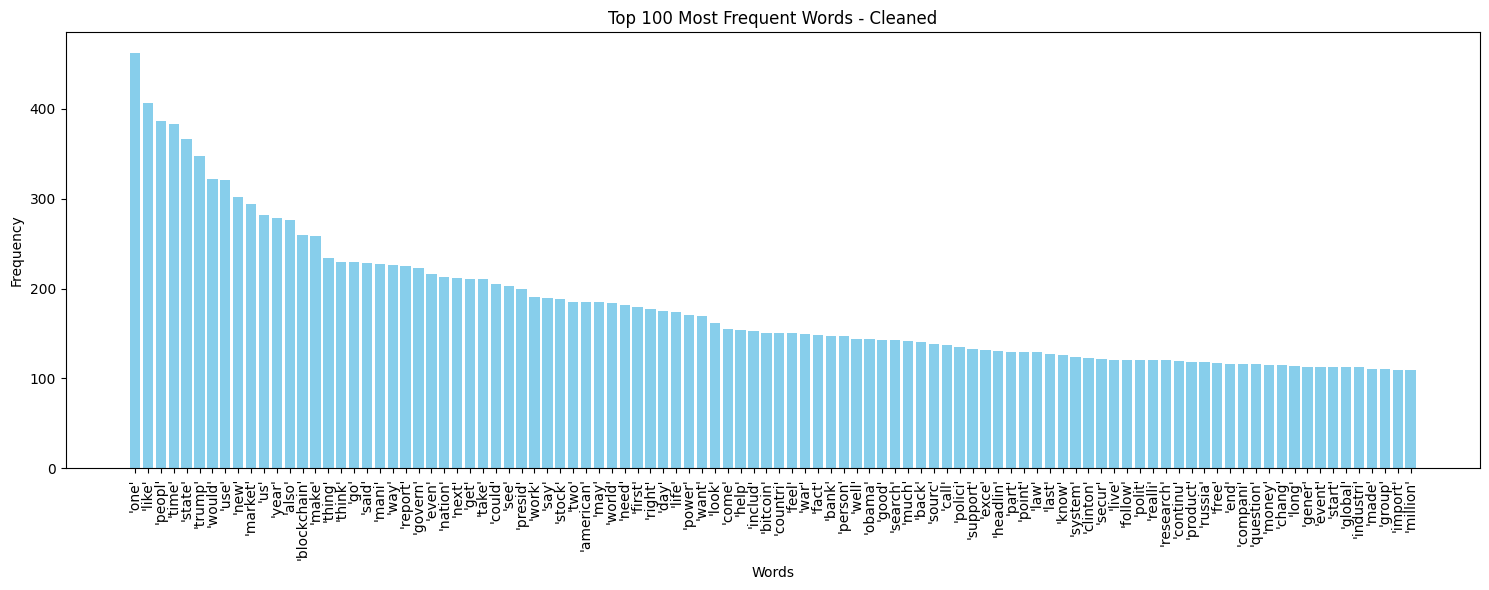

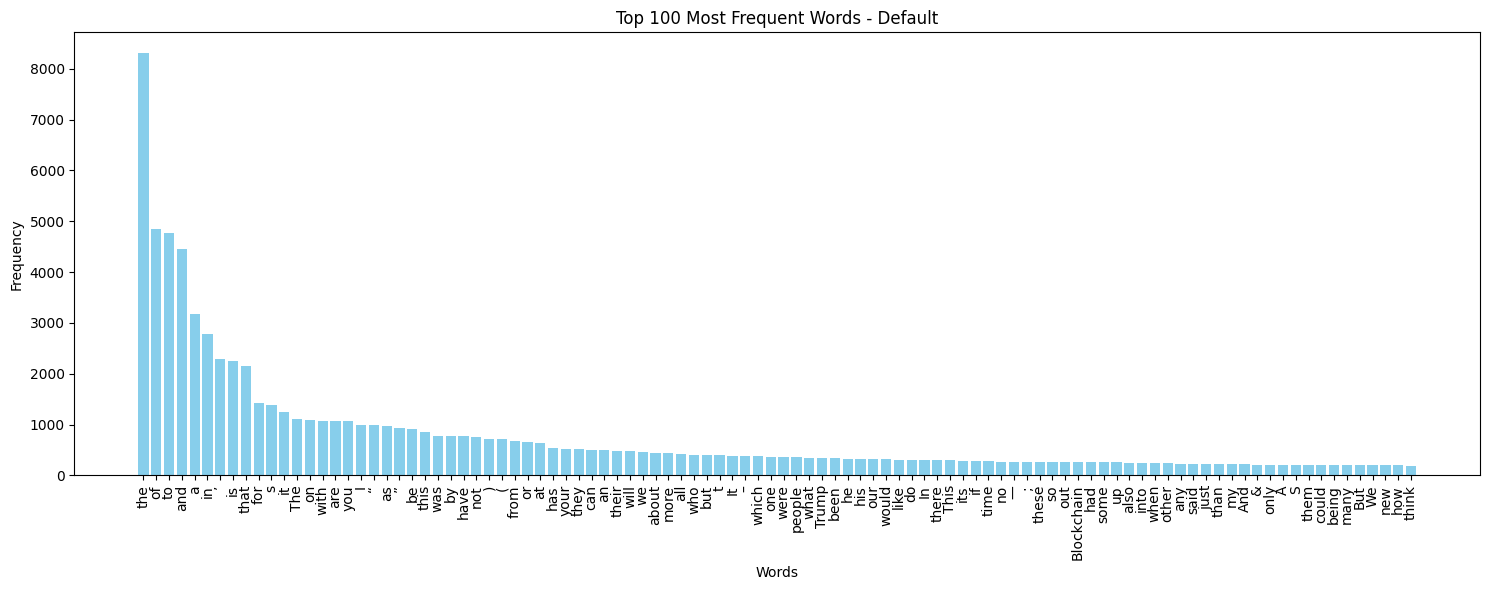

unreliable
fake
clickbait
conspiracy
reliable
bias
hate
junksci
political
nan
unknown
How many unique types are there?: 11
There are 0 nan type articles, and 6 unknown articles


In [7]:
import re 
import csv 
import matplotlib.pyplot as plt

with open("output.txt", newline="") as file:
    reader = csv.reader(file)
    data = "\n".join([", ".join(row) for row in reader])

def countNum(data):
    hash = {}
    pattern = "[^ |,|\t|\n|:|-|\.|\?|\!]+"
    match = re.findall(pattern, data)

    for i in match: 
        if i not in hash:
            hash[i] = 1
        else:
            hash[i] += 1
    return hash

def sortlist(d):
    d = d.copy()  
    sorted_list = []

    while d:
        max_key = max(d, key=d.get)
        sorted_list.append((d[max_key], max_key))
        del d[max_key]

    return sorted_list

# Make the untoched data fit the function and then sort the frequency
all_tokens = [word for tokens in df["tokens"] for word in tokens]
all_tokens_string = " ".join(all_tokens) 
top_words_default = sortlist(countNum(all_tokens_string))[:100]

# Sort the data from the output.txt file which has been cleaned 
top_words_cleaned = sortlist(countNum(data))[:100]



words_default = [w for w, c in top_words_default]
counts_default = [c for w, c in top_words_default]

words_cleaned = [w for w, c in top_words_cleaned]
counts_cleaned = [c for w, c in top_words_cleaned]

# Plot the bar chart
plt.figure(figsize=(15, 6))  
plt.bar(counts_cleaned, words_cleaned, color='skyblue')
plt.xticks(rotation=90)      
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 100 Most Frequent Words - Cleaned')
plt.tight_layout()
plt.show()

# Plot the bar chart
plt.figure(figsize=(15, 6))  
plt.bar(counts_default, words_default, color='skyblue')
plt.xticks(rotation=90)      
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 100 Most Frequent Words - Default')
plt.tight_layout()
plt.show()

#Find out how many types there are.
unique_types = df["type"].unique()
for article_type in unique_types:
    print(article_type)
print(f"How many unique types are there?: {len(unique_types)}")

unknown = df[df["type"] == "unknown"]
nan = df[df["type"] == "nan"]
df["type"] = df["type"].str.strip()  # remove any surrounding whitespace
nan = df[df["type"] == "nan"]
print(f"There are {len(nan)} nan type articles, and {len(unknown)} unknown articles")